<a href="https://colab.research.google.com/github/ramsudheer241/rams0241/blob/master/Vulnerability_Exploitation_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install xgboost imbalanced-learn openpyxl shap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [3]:
import kagglehub
import os

path = kagglehub.dataset_download("krooz0/cve-and-cwe-mapping-dataset")

global_dataset = os.path.join(path, "Global_Dataset.xlsx")

df = pd.read_excel(global_dataset)

print(df.shape)

df.head()

100%|██████████| 31.1M/31.1M [00:00<00:00, 90.8MB/s]

Extracting files...


(169566, 7)


,ID,CVE-ID,CVSS-V3,CVSS-V2,SEVERITY,DESCRIPTION,CWE-ID
0,1,CVE-1999-0001,NaN,5.0,MEDIUM,ip_input.c in BSD-derived TCP/IP implementatio...,CWE-20
1,2,CVE-1999-0002,NaN,10.0,HIGH,Buffer overflow in NFS mountd gives root acces...,CWE-119
2,3,CVE-1999-0003,NaN,10.0,HIGH,Execute commands as root via buffer overflow i...,NVD-CWE-Other
3,4,CVE-1999-0004,NaN,5.0,MEDIUM,"MIME buffer overflow in email clients, e.g. So...",NVD-CWE-Other
4,5,CVE-1999-0005,NaN,10.0,HIGH,Arbitrary command execution via IMAP buffer ov...,NVD-CWE-Other


In [4]:
import requests

kev_url = "https://www.cisa.gov/sites/default/files/feeds/known_exploited_vulnerabilities.json"

kev = requests.get(kev_url).json()

kev_df = pd.DataFrame(kev["vulnerabilities"])

print(kev_df.shape)

kev_df.head()

(1653, 11)


,cveID,vendorProject,product,vulnerabilityName,dateAdded,shortDescription,requiredAction,dueDate,knownRansomwareCampaignUse,notes,cwes
0,CVE-2026-16232,Check Point,SmartConsole,Check Point SmartConsole Improper Authenticati...,2026-07-22,Check Point SmartConsole contains an improper ...,Apply mitigations in accordance with vendor in...,2026-07-25,Unknown,https://support.checkpoint.com/results/sk/sk18...,[CWE-287]
1,CVE-2026-50522,Microsoft,SharePoint,Microsoft SharePoint Deserialization of Untrus...,2026-07-22,Microsoft SharePoint contains a deserializatio...,Apply mitigations in accordance with vendor in...,2026-07-25,Unknown,https://msrc.microsoft.com/update-guide/vulner...,[CWE-502]
2,CVE-2026-60137,WordPress,Core,WordPress Core SQL Injection Vulnerability,2026-07-21,WordPress Core contains a SQL injection vulner...,Apply mitigations in accordance with vendor in...,2026-08-04,Unknown,https://wordpress.org/news/2026/07/wordpress-7...,[CWE-89]
3,CVE-2026-63030,WordPress,Core,WordPress Core Interpretation Conflict Vulnera...,2026-07-21,WordPress Core contains an interpretation conf...,Apply mitigations in accordance with vendor in...,2026-07-24,Unknown,https://wordpress.org/news/2026/07/wordpress-7...,[CWE-436]
4,CVE-2026-0770,Langflow,Langflow,Langflow Inclusion of Functionality from Untru...,2026-07-21,Langflow contains an inclusion of functionalit...,Apply mitigations in accordance with vendor in...,2026-07-24,Unknown,https://github.com/langflow-ai/langflow/releas...,[CWE-829]


In [5]:
df = df.rename(columns={
    "CVE-ID":"cveID",
    "CVSS-V3":"cvss_v3",
    "CVSS-V2":"cvss_v2",
    "SEVERITY":"severity",
    "DESCRIPTION":"description",
    "CWE-ID":"cwe"
})

df.head()

,ID,cveID,cvss_v3,cvss_v2,severity,description,cwe
0,1,CVE-1999-0001,NaN,5.0,MEDIUM,ip_input.c in BSD-derived TCP/IP implementatio...,CWE-20
1,2,CVE-1999-0002,NaN,10.0,HIGH,Buffer overflow in NFS mountd gives root acces...,CWE-119
2,3,CVE-1999-0003,NaN,10.0,HIGH,Execute commands as root via buffer overflow i...,NVD-CWE-Other
3,4,CVE-1999-0004,NaN,5.0,MEDIUM,"MIME buffer overflow in email clients, e.g. So...",NVD-CWE-Other
4,5,CVE-1999-0005,NaN,10.0,HIGH,Arbitrary command execution via IMAP buffer ov...,NVD-CWE-Other


In [6]:
df["cvss_score"] = df["cvss_v3"]

mask = df["cvss_score"].isna()

df.loc[mask,"cvss_score"] = df.loc[mask,"cvss_v2"]

In [7]:
kev_set = set(kev_df["cveID"])

df["exploited"] = df["cveID"].isin(kev_set).astype(int)

df["exploited"].value_counts()

,count
exploited,
0,168642
1,924


In [8]:
df = df[
    [
        "cveID",
        "description",
        "severity",
        "cwe",
        "cvss_score",
        "exploited"
    ]
]

df.head()

,cveID,description,severity,cwe,cvss_score,exploited
0,CVE-1999-0001,ip_input.c in BSD-derived TCP/IP implementatio...,MEDIUM,CWE-20,5.0,0
1,CVE-1999-0002,Buffer overflow in NFS mountd gives root acces...,HIGH,CWE-119,10.0,0
2,CVE-1999-0003,Execute commands as root via buffer overflow i...,HIGH,NVD-CWE-Other,10.0,0
3,CVE-1999-0004,"MIME buffer overflow in email clients, e.g. So...",MEDIUM,NVD-CWE-Other,5.0,0
4,CVE-1999-0005,Arbitrary command execution via IMAP buffer ov...,HIGH,NVD-CWE-Other,10.0,0


In [9]:
df.isnull().sum()

,0
cveID,0
description,0
severity,86
cwe,0
cvss_score,86
exploited,0


In [10]:
df["severity"] = df["severity"].fillna("UNKNOWN")

df["cwe"] = df["cwe"].fillna("UNKNOWN")

df["description"] = df["description"].fillna("")

df["cvss_score"] = df["cvss_score"].fillna(df["cvss_score"].median())

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169566 entries, 0 to 169565
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   cveID        169566 non-null  object 
 1   description  169566 non-null  object 
 2   severity     169566 non-null  object 
 3   cwe          169566 non-null  object 
 4   cvss_score   169566 non-null  float64
 5   exploited    169566 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 7.8+ MB


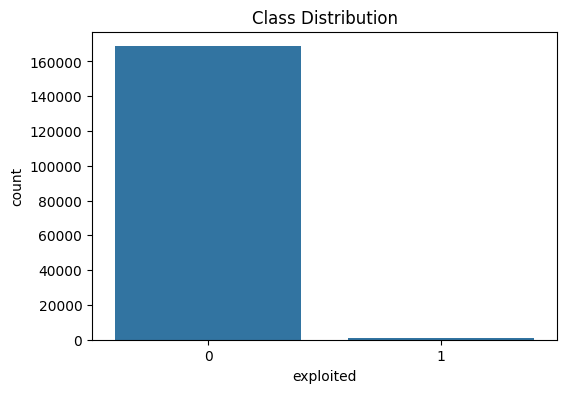

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="exploited")

plt.title("Class Distribution")

plt.show()

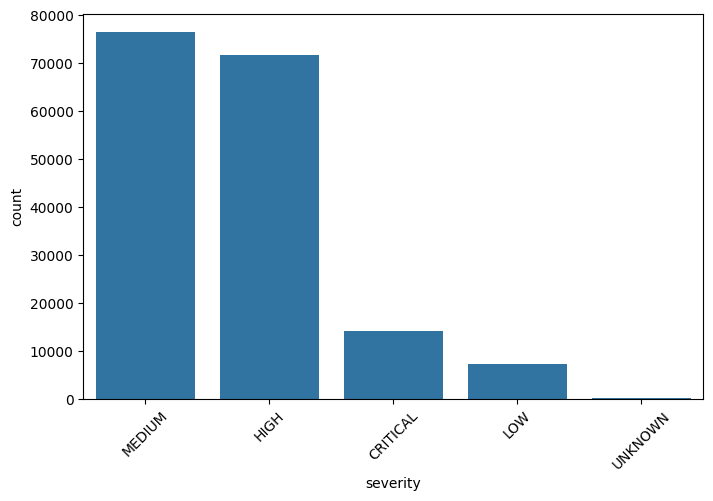

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="severity",
    order=df["severity"].value_counts().index
)

plt.xticks(rotation=45)

plt.show()

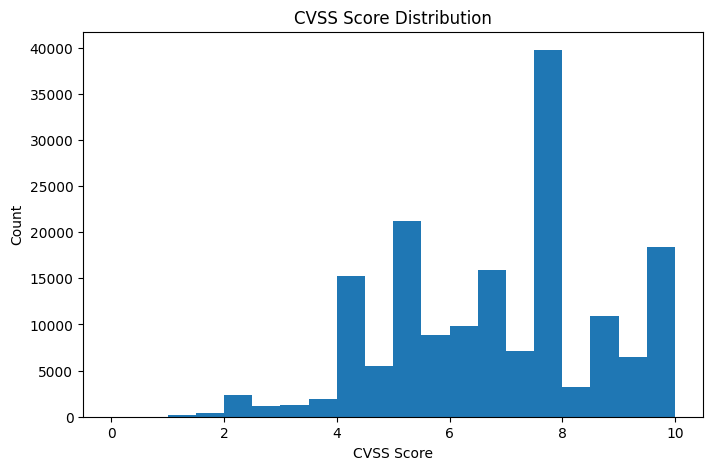

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["cvss_score"],bins=20)

plt.xlabel("CVSS Score")

plt.ylabel("Count")

plt.title("CVSS Score Distribution")

plt.show()

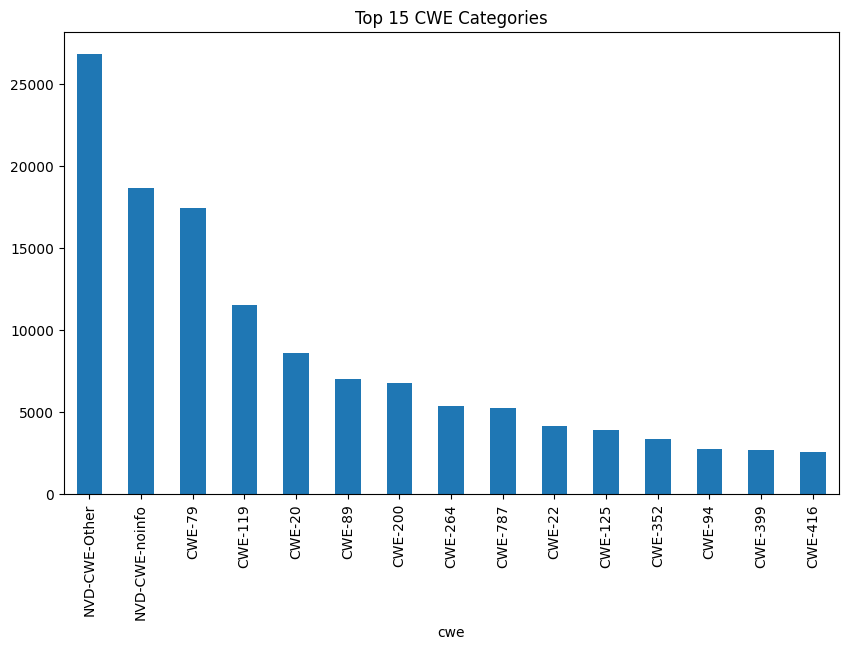

In [15]:
plt.figure(figsize=(10,6))

df["cwe"].value_counts().head(15).plot(kind="bar")

plt.title("Top 15 CWE Categories")

plt.show()

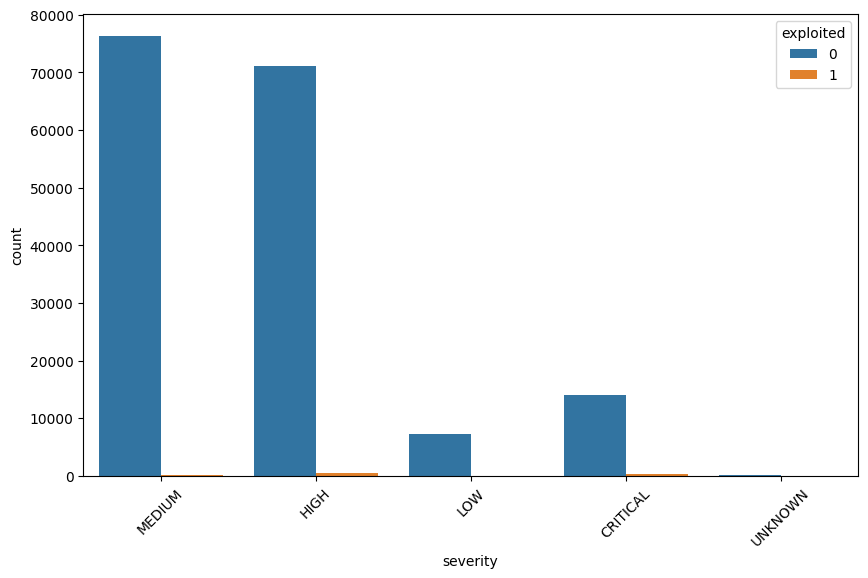

In [16]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="severity",
    hue="exploited"
)

plt.xticks(rotation=45)

plt.show()

In [17]:
df.describe(include="all")

,cveID,description,severity,cwe,cvss_score,exploited
count,169566,169566,169566,169566,169566.000000,169566.000000
unique,166337,161599,5,306,NaN,NaN
top,CVE-2019-14480,A remote code execution vulnerability was iden...,MEDIUM,NVD-CWE-Other,NaN,NaN
freq,5,83,76460,26834,NaN,NaN
mean,NaN,NaN,NaN,NaN,6.796177,0.005449
std,NaN,NaN,NaN,NaN,1.889631,0.073618
min,NaN,NaN,NaN,NaN,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,5.300000,0.000000
50%,NaN,NaN,NaN,NaN,7.100000,0.000000
75%,NaN,NaN,NaN,NaN,7.800000,0.000000


In [18]:
print(df.shape)

print(df.head())

print(df["exploited"].value_counts())

(169566, 6)
           cveID                                        description severity  \
0  CVE-1999-0001  ip_input.c in BSD-derived TCP/IP implementatio...   MEDIUM   
1  CVE-1999-0002  Buffer overflow in NFS mountd gives root acces...     HIGH   
2  CVE-1999-0003  Execute commands as root via buffer overflow i...     HIGH   
3  CVE-1999-0004  MIME buffer overflow in email clients, e.g. So...   MEDIUM   
4  CVE-1999-0005  Arbitrary command execution via IMAP buffer ov...     HIGH   

             cwe  cvss_score  exploited  
0         CWE-20         5.0          0  
1        CWE-119        10.0          0  
2  NVD-CWE-Other        10.0          0  
3  NVD-CWE-Other         5.0          0  
4  NVD-CWE-Other        10.0          0  
exploited
0    168642
1       924
Name: count, dtype: int64


In [19]:
print(df["exploited"].value_counts(normalize=True) * 100)

exploited
0    99.455079
1     0.544921
Name: proportion, dtype: float64


In [20]:
positive = df[df["exploited"] == 1]

negative = df[df["exploited"] == 0]

print(len(positive))
print(len(negative))

924
168642


In [21]:
negative_sample = negative.sample(
    n=len(positive) * 3,
    random_state=42
)

balanced_df = pd.concat([positive, negative_sample])

balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

balanced_df.shape

(3696, 6)

In [22]:
balanced_df["exploited"].value_counts()

,count
exploited,
0,2772
1,924


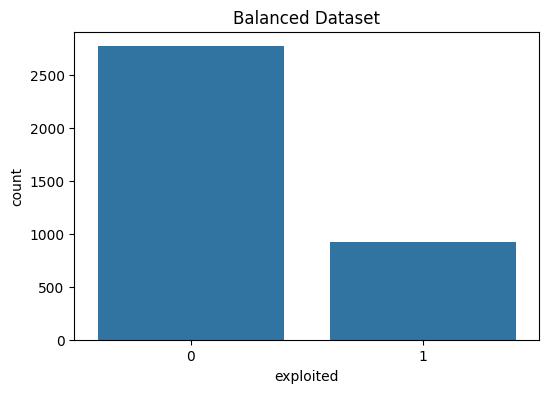

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(data=balanced_df, x="exploited")

plt.title("Balanced Dataset")

plt.show()

In [24]:
balanced_df.to_csv("balanced_dataset.csv", index=False)

balanced_df.head()

,cveID,description,severity,cwe,cvss_score,exploited
0,CVE-2019-7270,Linear eMerge 50P/5000P devices allow Cross-Si...,HIGH,CWE-352,8.8,0
1,CVE-2020-5722,The HTTP interface of the Grandstream UCM6200 ...,CRITICAL,CWE-89,9.8,1
2,CVE-2017-5689,An unprivileged network attacker could gain sy...,CRITICAL,NVD-CWE-noinfo,9.8,1
3,CVE-2021-29049,Cross-site scripting (XSS) vulnerability in th...,MEDIUM,CWE-79,6.1,0
4,CVE-2015-4692,The kvm_apic_has_events function in arch/x86/k...,MEDIUM,NVD-CWE-Other,4.9,0


In [25]:
X = df.drop(columns=["cveID", "exploited"])

y = df["exploited"]

print(X.shape)
print(y.shape)

(169566, 4)
(169566,)


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(135652, 4)
(33914, 4)


In [27]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(scale_pos_weight)

182.5615696887686


In [28]:
from sklearn.compose import ColumnTransformer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline

In [29]:
text_feature = "description"

categorical_features = [
    "severity",
    "cwe"
]

numeric_features = [
    "cvss_score"
]

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                stop_words="english",
                max_features=5000
            ),
            text_feature
        ),

        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),

        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [32]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier",
     LogisticRegression(
         max_iter=1000,
         class_weight="balanced",
         random_state=42
     ))
])

In [33]:
lr_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000,
                                                                  stop_words='english'),
                                                  'description'),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['severity', 'cwe']),
                                                 ('num', 'passthrough',
                                                  ['cvss_score'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [34]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier",
     RandomForestClassifier(
         n_estimators=200,
         class_weight="balanced",
         random_state=42,
         n_jobs=-1
     ))
])

In [35]:
rf_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000,
                                                                  stop_words='english'),
                                                  'description'),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['severity', 'cwe']),
                                                 ('num', 'passthrough',
                                                  ['cvss_score'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [36]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier",
     XGBClassifier(
         n_estimators=200,
         learning_rate=0.05,
         max_depth=6,
         subsample=0.8,
         colsample_bytree=0.8,
         scale_pos_weight=scale_pos_weight,
         random_state=42,
         eval_metric="logloss"
     ))
])

In [ ]:
xgb_pipeline.fit(
    X_train,
    y_train
)

In [ ]:
lr_pred = lr_pipeline.predict(X_test)

rf_pred = rf_pipeline.predict(X_test)

xgb_pred = xgb_pipeline.predict(X_test)

In [ ]:
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]

rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

In [ ]:
print("LOGISTIC REGRESSION")
print("="*50)

print(classification_report(y_test, lr_pred))

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC AUC  :", roc_auc_score(y_test, lr_prob))

In [ ]:
print("RANDOM FOREST")
print("="*50)

print(classification_report(y_test, rf_pred))

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf_prob))

In [ ]:
print("XGBOOST")
print("="*50)

print(classification_report(y_test, xgb_pred))

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC AUC  :", roc_auc_score(y_test, xgb_prob))

In [ ]:
models = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

for name, pred in models.items():

    plt.figure(figsize=(5,4))

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(name)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

In [ ]:
plt.figure(figsize=(8,6))

fpr, tpr, _ = roc_curve(y_test, lr_prob)
plt.plot(fpr, tpr, label="Logistic Regression")

fpr, tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr, tpr, label="Random Forest")

fpr, tpr, _ = roc_curve(y_test, xgb_prob)
plt.plot(fpr, tpr, label="XGBoost")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

precision, recall, _ = precision_recall_curve(y_test, lr_prob)
plt.plot(recall, precision, label="Logistic Regression")

precision, recall, _ = precision_recall_curve(y_test, rf_prob)
plt.plot(recall, precision, label="Random Forest")

precision, recall, _ = precision_recall_curve(y_test, xgb_prob)
plt.plot(recall, precision, label="XGBoost")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

In [ ]:
models = {
    "Logistic Regression": lr_prob,
    "Random Forest": rf_prob,
    "XGBoost": xgb_prob
}

for name, prob in models.items():

    precision, recall, _ = precision_recall_curve(y_test, prob)

    pr_auc = auc(recall, precision)

    print(f"{name} PR-AUC: {pr_auc:.4f}")

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest","XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

results = results.sort_values("F1", ascending=False)

results

In [ ]:
best_model = results.iloc[0]["Model"]

print("Best Model:", best_model)

In [ ]:
if best_model == "Logistic Regression":
    final_model = lr_pipeline

elif best_model == "Random Forest":
    final_model = rf_pipeline

else:
    final_model = xgb_pipeline

joblib.dump(final_model, "best_model.pkl")

print("Model saved successfully.")

In [ ]:
xgb_model = xgb_pipeline.named_steps["classifier"]

importance = xgb_model.feature_importances_

plt.figure(figsize=(10,4))
plt.plot(np.sort(importance)[::-1][:50])

plt.title("Top 50 XGBoost Feature Importances")

plt.xlabel("Feature Rank")

plt.ylabel("Importance")

plt.show()

In [ ]:
results.to_csv("model_results.csv", index=False)

results

In [ ]:
print("="*60)
print("PROJECT CONCLUSION")
print("="*60)

print("""
This project developed machine learning models to predict whether a
Common Vulnerabilities and Exposures (CVE) entry is likely to be
actively exploited using publicly available vulnerability information.

The workflow included:

• Data collection from the Kaggle CVE dataset and CISA KEV catalog
• Data cleaning and preprocessing
• Feature engineering using TF-IDF, categorical encoding, and CVSS scores
• Handling severe class imbalance using model-specific weighting
• Training Logistic Regression, Random Forest, and XGBoost models
• Evaluation using Precision, Recall, F1-score, ROC-AUC, and PR-AUC

Among the evaluated models, Random Forest achieved the highest F1-score,
while Logistic Regression and XGBoost achieved higher recall.
The choice of the best model depends on whether minimizing false positives
or maximizing the detection of exploited vulnerabilities is the priority.

Overall, the project demonstrates the effectiveness of machine learning
for cybersecurity risk assessment and highlights the challenges posed by
highly imbalanced vulnerability datasets.
""")

In [ ]:
df.to_csv("processed_dataset.csv", index=False)

In [ ]:
print("Files generated:")
print("✔ processed_dataset.csv")
print("✔ model_results.csv")
print("✔ best_model.pkl")